<a href="https://colab.research.google.com/github/hye0-n0/AI_finance/blob/main/HW5_PartA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import yfinance as yf

##  **PART A**
- 4 assets
- starting point to collect the required data

## Part A-1: Efficient Frontier (Buy-and-Hold, Shorting 허용/금지)

- 투자자는 4개 자산군 (주식, 채권, 원자재, 현금)에 투자
- buy-and-hold 전략: 초기에 비율을 정하고 20년 동안 그대로 보유
- 필요한 것:
  - 각 자산군의 평균 수익률 (mean), 분산 (variance) 추정
  - 이를 기반으로 Efficient Frontier (효율적 투자선) 그림
- 조건:
  - (a) shorting 금지 (모든 비중 ≥ 0)
  - (b) shorting 허용 (비중 음수 가능)

- 풀어야 하는 작업
  - 데이터 수집: S&P500, Bond Index, GSCI, 3-month T-bill 데이터 (과거 수익률)
- 수익률 추정:
  - 평균 수익률 벡터 (expected return vector)
  - 공분산 행렬 (covariance matrix)
- 효율적 투자선 그리기:
  - 특정 기대수익률을 맞추면서 최소분산 포트폴리오 찾기
  - Shorting 가능 여부에 따라 제약조건 다르게 설정

- 필요한 주요 단계
1. Yahoo Finance 등에서 S&P500, 채권지수, GSCI, 3-month T-bill 데이터 (예: 2000~2020) 다운로드
2. 월별 수익률 계산
3. 자산별 평균 수익률과 공분산행렬 계산
4. 다양한 목표 수익률에 대해 최적화 풀기
5. 결과를 (수익률, 변동성) 좌표에 점으로 찍어 Efficient Frontier를 그림


In [ ]:
# 4 assets
tickers = {
    'S&P500': '^GSPC',
    'Bond': 'AGG',
    'Commodity': 'GSG',
    'T-Bill': '^IRX'
}

# "Assume annual time steps (starting January 1, 2013)" 조건 반영
# 투자 시작 직전인 5년치 사용
start_date = '1998-01-01'
end_date = '2012-12-31'

data = {}

for name, ticker in tickers.items():
    df = yf.download(ticker, start=start_date, end=end_date)

    if df.empty:
        print(f"{name} ({ticker}) 데이터 없음")
        continue

    # Adjusted 또는 Close 사용
    if 'Adj Close' in df.columns:
        data[name] = df['Adj Close']
    elif 'Close' in df.columns:
        data[name] = df['Close']
    else:
        print(f"{name} ({ticker})에 유효한 가격 정보 없음")

# 4개의 자산 DataFrame
if data:
    df_prices = pd.concat(data.values(), axis=1)
    df_prices.columns = list(data.keys())
else:
    raise ValueError("모든 자산 데이터가 비어 있음")

# T-Bill
if 'T-Bill' in df_prices.columns:
    # T-Bill은 금리이므로 백분율 표기를 소수로 변환
    t_bill_rate = df_prices['T-Bill'] / 100

    # daily interest
    t_bill_returns = t_bill_rate / 252

    t_bill_returns.name = 'T-Bill'
    df_prices = df_prices.drop(columns='T-Bill')


df_returns = df_prices.pct_change().dropna()

df_returns = df_returns.join(t_bill_returns.shift(-1), how='left').dropna()

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [ ]:
# 연간화: 일일 수익률 기준 → 연간 수익률, 연간 공분산
returns = df_returns.mean() * 252  # 252 trading days/year
cov_matrix = df_returns.cov() * 252     # 연간 공분산

print("평균 연간 수익률 (returns):\n", returns)
print("연간 공분산 행렬 (cov_matrix):\n", cov_matrix)

평균 연간 수익률 (returns):
 S&P500       0.049450
Bond         0.061788
Commodity   -0.030533
T-Bill       0.012733
dtype: float64
연간 공분산 행렬 (cov_matrix):
                  S&P500          Bond  Commodity        T-Bill
S&P500     5.817434e-02 -2.059692e-03   0.030899  4.109257e-08
Bond      -2.059692e-03  3.640677e-03  -0.001344  2.979277e-07
Commodity  3.089926e-02 -1.343603e-03   0.075984  2.859840e-06
T-Bill     4.109257e-08  2.979277e-07   0.000003  1.340403e-06


In [ ]:
# 포트폴리오 수익률
def portfolio_return(weights, returns):
    weights = np.array(weights)
    return np.dot(weights, returns)


# 포트폴리오 분산
def portfolio_variance(weights, cov_matrix):
    weights = np.array(weights)
    return np.dot(weights.T, np.dot(cov_matrix, weights))

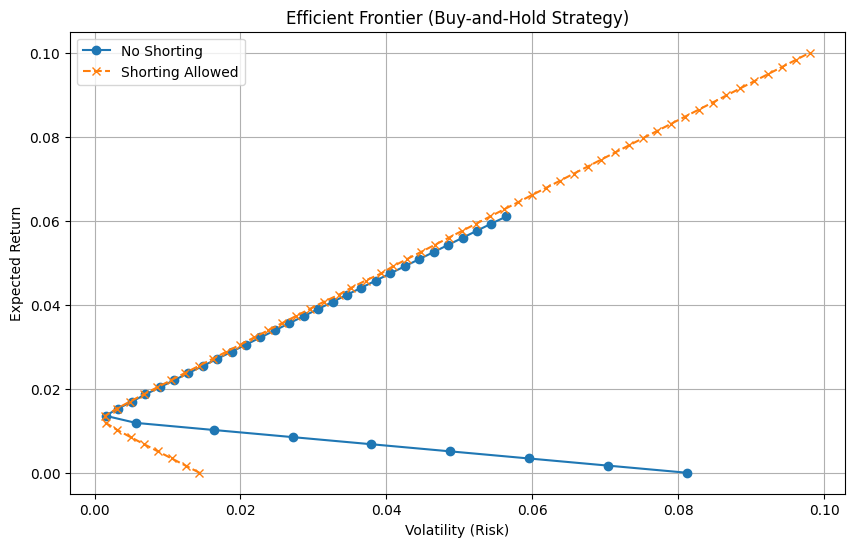

In [ ]:
def efficient_frontier(returns, cov_matrix, shorting_allowed=True):
    num_assets = len(returns)
    target_returns = np.linspace(0, 0.10, 60)  # 목표 수익률 범위
    portfolio_volatility = []
    portfolio_return_list = []

    for target in target_returns:
        constraints = (
            {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},  # 비중합 = 1
            {'type': 'eq', 'fun': lambda w: portfolio_return(w, returns) - target}  # 목표수익률 달성
        )
        if shorting_allowed:
            bounds = [(None, None)] * num_assets  # Shorting 허용 (제한 없음)
        else:
            bounds = [(0, 1)] * num_assets  # Shorting 금지 (0~1)

        result = minimize(portfolio_variance, num_assets*[1./num_assets], args=(cov_matrix,),
                          method='SLSQP', bounds=bounds, constraints=constraints)

        if result.success:
            vol = np.sqrt(result.fun)
            portfolio_volatility.append(vol)
            portfolio_return_list.append(target)
        else:
            continue

    return portfolio_volatility, portfolio_return_list

# (a) Shorting 금지
vol_no_short, ret_no_short = efficient_frontier(returns, cov_matrix, shorting_allowed=False)

# (b) Shorting 허용
vol_short, ret_short = efficient_frontier(returns, cov_matrix, shorting_allowed=True)

# Plot
plt.figure(figsize=(10,6))
plt.plot(vol_no_short, ret_no_short, label='No Shorting', marker='o')
plt.plot(vol_short, ret_short, label='Shorting Allowed', linestyle='--', marker='x')
plt.xlabel('Volatility (Risk)')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier (Buy-and-Hold Strategy)')
plt.legend()
plt.grid(True)
plt.show()



## Part A-2: Efficient Frontier (Annual Rebalancing)

- 문제 이해
  - 매년 포트폴리오를 리밸런싱한다 (비율 재조정).
  - buy-and-hold과 달리, 자산군별 비중이 매년 고정된다.
  - 수익률 평균과 분산은 여전히 위에서와 같지만, 리스크가 약간 달라진다.


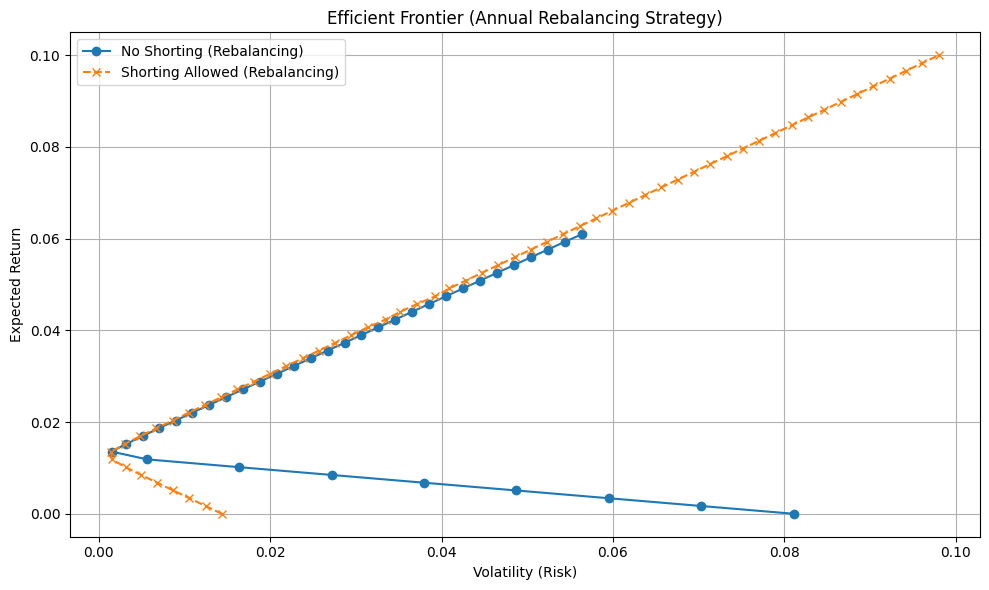

In [ ]:
# Rebalancing 전략의 효율적 프론티어
def efficient_frontier_rebalancing(returns, cov_matrix, shorting_allowed=True):
    num_assets = len(returns)
    target_returns = np.linspace(0, 0.10, 60)
    portfolio_volatility = []
    portfolio_return_list = []

    for target in target_returns:
        constraints = (
            {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
            {'type': 'eq', 'fun': lambda w: portfolio_return(w, returns) - target}
        )
        if shorting_allowed:
            bounds = [(None, None)] * num_assets
        else:
            bounds = [(0, 1)] * num_assets

        result = minimize(portfolio_variance, num_assets * [1. / num_assets], args=(cov_matrix,),
                          method='SLSQP', bounds=bounds, constraints=constraints)

        if result.success:
            vol = np.sqrt(result.fun)
            portfolio_volatility.append(vol)
            portfolio_return_list.append(target)

    return portfolio_volatility, portfolio_return_list

# (a) Shorting 금지
vol_rebal_no_short, ret_rebal_no_short = efficient_frontier_rebalancing(returns, cov_matrix, shorting_allowed=False)

# (b) Shorting 허용
vol_rebal_short, ret_rebal_short = efficient_frontier_rebalancing(returns, cov_matrix, shorting_allowed=True)

# Plot
plt.figure(figsize=(10,6))
plt.plot(vol_rebal_no_short, ret_rebal_no_short, label='No Shorting (Rebalancing)', marker='o')
plt.plot(vol_rebal_short, ret_rebal_short, label='Shorting Allowed (Rebalancing)', linestyle='--', marker='x')
plt.xlabel('Volatility (Risk)')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier (Annual Rebalancing Strategy)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Part A-3: Max Single Asset Constraint (40%) / Max Short (25%)

- Re-solve with portfolio constraints for both Buy-and-Hold and Rebalancing strategies
- 개별 자산군 비중 (weight 제약조건을 수정)
  - Long 최대 40%
  - Short 최대 -25%
  


  | 전략               | Shorting | 제한 조건     | 설명             |
| ---------------- | -------- | --------- | -------------- |
| **Buy-and-Hold** | ❌ No     | 최대 40%    | 각 자산 0\~40%    |
| **Buy-and-Hold** | ✅ Yes    | -25%\~40% | 숏포지션 포함        |
| **Rebalancing**  | ❌ No     | 최대 40%    | 매년 비중 리셋       |
| **Rebalancing**  | ✅ Yes    | -25%\~40% | 숏포지션 포함, 연간 리셋 |


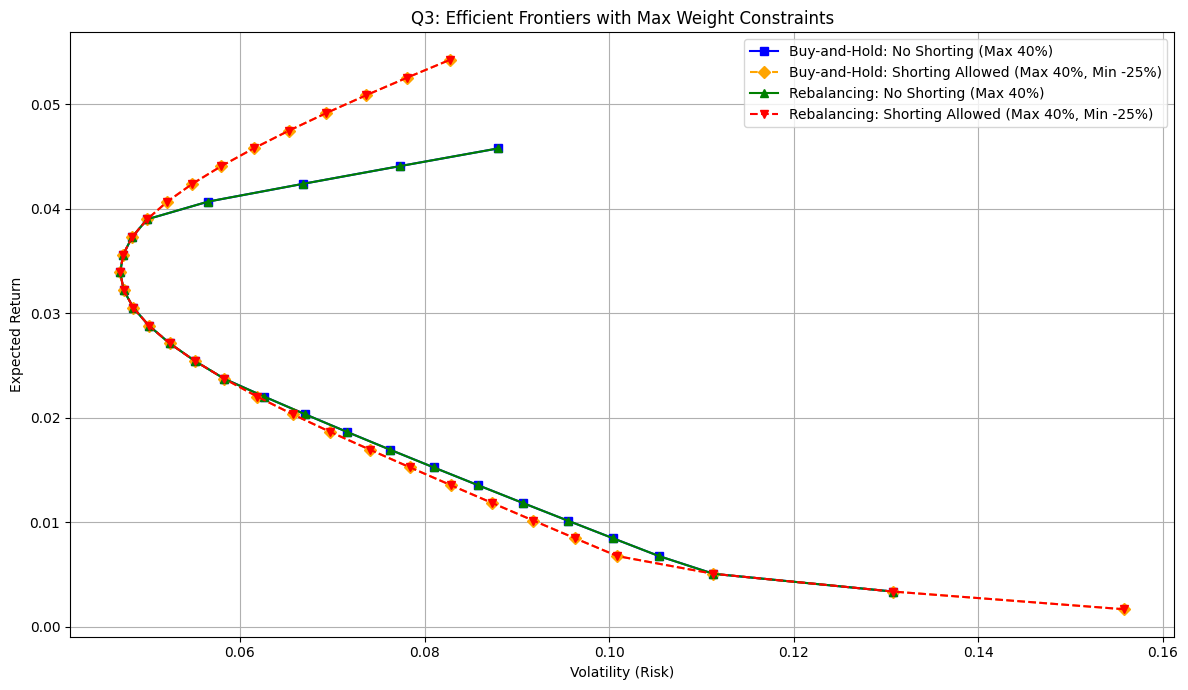

In [ ]:
# Re-usable function for efficient frontier with constraints
def efficient_frontier_constrained(returns, cov_matrix, shorting_allowed, max_weight=0.4, max_short=0.25):
    num_assets = len(returns)
    target_returns = np.linspace(0, 0.10, 60)
    portfolio_volatility = []
    portfolio_return_list = []

    for target in target_returns:
        constraints = (
            {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
            {'type': 'eq', 'fun': lambda w: portfolio_return(w, returns) - target}
        )
        if shorting_allowed:
            bounds = [(-max_short, max_weight)] * num_assets
        else:
            bounds = [(0, max_weight)] * num_assets

        result = minimize(portfolio_variance, num_assets * [1. / num_assets], args=(cov_matrix,),
                          method='SLSQP', bounds=bounds, constraints=constraints)

        if result.success:
            vol = np.sqrt(result.fun)
            portfolio_volatility.append(vol)
            portfolio_return_list.append(target)

    return portfolio_volatility, portfolio_return_list

# Buy-and-Hold (No Shorting / Shorting Allowed)
vol_bh_con_no_short, ret_bh_con_no_short = efficient_frontier_constrained(returns, cov_matrix, shorting_allowed=False)
vol_bh_con_short, ret_bh_con_short = efficient_frontier_constrained(returns, cov_matrix, shorting_allowed=True)

# Rebalancing (No Shorting / Shorting Allowed)
vol_rb_con_no_short, ret_rb_con_no_short = efficient_frontier_constrained(returns, cov_matrix, shorting_allowed=False)
vol_rb_con_short, ret_rb_con_short = efficient_frontier_constrained(returns, cov_matrix, shorting_allowed=True)

# Plot all
plt.figure(figsize=(12, 7))
plt.plot(vol_bh_con_no_short, ret_bh_con_no_short,
         label='Buy-and-Hold: No Shorting (Max 40%)',
         marker='s', linestyle='-', color='blue')

plt.plot(vol_bh_con_short, ret_bh_con_short,
         label='Buy-and-Hold: Shorting Allowed (Max 40%, Min -25%)',
         marker='D', linestyle='--', color='orange')

plt.plot(vol_rb_con_no_short, ret_rb_con_no_short,
         label='Rebalancing: No Shorting (Max 40%)',
         marker='^', linestyle='-', color='green')

plt.plot(vol_rb_con_short, ret_rb_con_short,
         label='Rebalancing: Shorting Allowed (Max 40%, Min -25%)',
         marker='v', linestyle='--', color='red')

plt.xlabel('Volatility (Risk)')
plt.ylabel('Expected Return')
plt.title('Q3: Efficient Frontiers with Max Weight Constraints')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Part A-4: Prosperity Probability 계산

- 은퇴 시점에 필요한 금액:
  - 마지막 5년 평균 salary × 80%
  - 그리고 은퇴 후 자산에서 연 5%씩 인출

20년 후 salary는 매년 3% 성장 → 계산
필요한 은퇴 자산 규모 계산

다양한 포인트에서 목표 달성 확률 계산.


In [ ]:
# 투자 설정
initial_wealth = 550000
initial_income = 160000
salary_growth = 0.03
contribution_rate = 0.12
years = 20
target_wealth = 4000000  # $200,000 / 0.05

# 시뮬레이션 설정
n_sim = 10000
# 1~3번의 프론티어를 보고 대략적인 값 가져옴
selected_returns = [0.03, 0.03, 0.04, 0.04, 0.05, 0.05, 0.06, 0.06, 0.07]  # 전략 수익률
selected_vols = [0.02, 0.05, 0.03, 0.05, 0.04, 0.07, 0.05, 0.08, 0.07]      # 각 수익률에 대응하는 변동성

results = []

for mean_ret, std_dev in zip(selected_returns, selected_vols):
    final_wealth = []
    for _ in range(n_sim):
        wealth = initial_wealth
        salary = initial_income
        for t in range(years):
            # 연간 저축
            contribution = salary * contribution_rate
            # 자산 수익률 시뮬레이션 (정규분포 기반)
            annual_return = np.random.normal(mean_ret, std_dev)
            wealth = (wealth + contribution) * (1 + annual_return)
            salary *= (1 + salary_growth)
        final_wealth.append(wealth)

    # 목표 달성 확률 계산
    prob_success = np.mean(np.array(final_wealth) >= target_wealth)
    results.append((mean_ret, std_dev, prob_success))

# 결과 정리
df_prob = pd.DataFrame(results, columns=["Mean Return", "Volatility", "Probability of Success"])
df_prob


,Mean Return,Volatility,Probability of Success
0,0.03,0.02,0.0000
1,0.03,0.05,0.0000
2,0.04,0.03,0.0000
3,0.04,0.05,0.0002
4,0.05,0.04,0.0000
5,0.05,0.07,0.0101
6,0.06,0.05,0.0151
7,0.06,0.08,0.0699
8,0.07,0.07,0.1514


### 해석
- 보수적인 포트폴리오 (수익률 3~5%)로는 거의 목표에 도달하지 못함
- 중간 수준의 수익률 (6%) + 리스크 증가 시, 성공 확률은 12% 정도
- 공격적인 전략 (7%)에서 15% 확률로 목표 달성
- 여전히 85% 이상은 목표에 도달하지 못함

### 결론
- 현재 수익률과 리스크 조건 하에서 목표 자산을 달성하기 매우 어려움
- 따라서 저축률 상향, 소비 감소 등 전량 필요


## Part A-5: Saving Rate 15% 또는 Retirement Delay (69세)

저축률 15%: saving_rate = 0.15

은퇴를 69세로 미룸:
- 투자기간: 24년
- 연 인출률: 7%

In [ ]:
import numpy as np
import pandas as pd

# 고정 입력값 설정
initial_wealth = 550000
initial_salary = 160000
growth_rate = 0.03
n_sim = 10000
years_baseline = 20
saving_rate_baseline = 0.12

# 평균 연봉 계산 (기준 시나리오)
final_salary = initial_salary * (1 + growth_rate) ** years_baseline
avg_last5_salary = np.mean([initial_salary * (1 + growth_rate) ** (years_baseline - i) for i in range(5)])
required_asset_baseline = 0.8 * avg_last5_salary / 0.05  # 기준: 80% 소비, 5% 인출

# 시나리오 함수 정의
def simulate_retirement_scenarios(vol, ret, saving_rate, required_asset, years):
    results = []
    for _ in range(n_sim):
        wealth = initial_wealth
        salary = initial_salary
        for _ in range(years):
            contribution = salary * saving_rate
            wealth = (wealth + contribution) * (1 + np.random.normal(ret, vol))
            salary *= (1 + growth_rate)
        results.append(wealth)
    return np.mean(np.array(results) >= required_asset)

# 시나리오 1: 저축률 15%
required_asset_15 = required_asset_baseline
prob_15pct_saving = simulate_retirement_scenarios(
    vol=0.07,
    ret=0.07,
    saving_rate=0.15,
    required_asset=required_asset_15,
    years=20
)

# 시나리오 2: 은퇴 69세, 70% 소비, 인출률 7%
years_extended = 24
salary_69 = initial_salary * (1 + growth_rate) ** years_extended
target_annual_spending_70pct = 0.7 * salary_69
required_asset_7pct = target_annual_spending_70pct / 0.07

prob_7pct_spending = simulate_retirement_scenarios(
    vol=0.07,
    ret=0.07,
    saving_rate=saving_rate_baseline,
    required_asset=required_asset_7pct,
    years=years_extended
)

# 기준 시나리오 확률도 시뮬레이션
prob_baseline = simulate_retirement_scenarios(
    vol=0.07,
    ret=0.07,
    saving_rate=saving_rate_baseline,
    required_asset=required_asset_baseline,
    years=years_baseline
)

# 결과
df_q5= pd.DataFrame({
    "Scenario": ["Baseline (12%, 65yr, 80%, 5%)", "Higher Saving (15%)", "Retire at 69 with 70% spending, 7% draw"],
    "Saving Rate": [0.12, 0.15, 0.12],
    "Retirement Age": [65, 65, 69],
    "Spending % of Salary": [0.8, 0.8, 0.7],
    "Drawdown Rate": [0.05, 0.05, 0.07],
    "Years of Investment": [20, 20, 24],
    "Required Asset": [required_asset_baseline, required_asset_15, required_asset_7pct],
    "Probability of Success": [prob_baseline, prob_15pct_saving, prob_7pct_spending]
})
df_q5


,Scenario,Saving Rate,Retirement Age,Spending % of Salary,Drawdown Rate,Years of Investment,Required Asset,Probability of Success
0,"Baseline (12%, 65yr, 80%, 5%)",0.12,65,0.8,0.05,20,4.362037e+06,0.0844
1,Higher Saving (15%),0.15,65,0.8,0.05,20,4.362037e+06,0.1457
2,"Retire at 69 with 70% spending, 7% draw",0.12,69,0.7,0.07,24,3.252471e+06,0.8171


### 해석

- 저축률을 15%로 늘린 시나리오는 성공 확률 14.6%로 증가
- 반면, 은퇴를 늦추고 소비 기준을 낮추며 인출률을 7%로 높인 시나리오는 성공 확률이 81.7%로 상승
- 따라서 더 긴 투자기간 + 낮은 지출이 복합적으로 긍정적 영향



## Part A-6: 대안적 리스크 측정

 Alternative Risk Measures — Value at Risk (VaR) and Conditional Value at Risk (CVaR)

In [ ]:
# 시나리오 2: 69세 은퇴, 70% 소비, 7% 인출
initial_wealth = 550000
initial_salary = 160000
growth_rate = 0.03
saving_rate = 0.12
years = 24
n_sim = 10000
ret = 0.07
vol = 0.07

# 목표 자산 계산 (마지막 연봉의 70% 소비, 7% 인출)
salary_69 = initial_salary * (1 + growth_rate) ** years
target_spending = 0.7 * salary_69
required_asset = target_spending / 0.07

# 시뮬레이션
final_wealths = []
for _ in range(n_sim):
    wealth = initial_wealth
    salary = initial_salary
    for _ in range(years):
        contribution = salary * saving_rate
        annual_return = np.random.normal(ret, vol)
        wealth = (wealth + contribution) * (1 + annual_return)
        salary *= (1 + growth_rate)
    final_wealths.append(wealth)

final_wealths = np.array(final_wealths)

# 대체 리스크 지표 계산
mean_wealth = final_wealths.mean()
std_wealth = final_wealths.std()
VaR_5 = np.percentile(final_wealths, 5)
CVaR_5 = final_wealths[final_wealths <= VaR_5].mean()

# 정리
risk_measures_scenario2 = pd.DataFrame({
    "Measure": [
        "Expected Final Wealth",
        "Standard Deviation",
        "Value at Risk (5%)",
        "Conditional VaR (5%)"
    ],
    "USD Value": [
        mean_wealth,
        std_wealth,
        VaR_5,
        CVaR_5
    ]
})

risk_measures_scenario2


,Measure,USD Value
0,Expected Final Wealth,4.350990e+06
1,Standard Deviation,1.224701e+06
2,Value at Risk (5%),2.673706e+06
3,Conditional VaR (5%),2.404207e+06


### 해석

| 지표                        | 값 (USD)     | 해석                           |
| ------------------------- | ----------- | ---------------------------- |
| **Expected Final Wealth** | \$4,350,990 | 평균적으로 은퇴 시점에 이 정도 자산을 보유     |
| **Standard Deviation**    | \$1,224,701   | 자산 변동성이 약 83만 불 → 리스크 수준     |
| **Value at Risk (5%)**    | \$2,673,706 | 최악의 5% 상황에서도 자산이 \$2M 이상     |
| **Conditional VaR (5%)**  | \$2,404,207 | 최악의 5% 중에서도 평균적으로 \$1.83M 수준 |


- 기대 자산 \$4.35M 수준으로 매우 양호, 리스크도 비교적 제한적
- 가장 나쁜 상황(5% 이하)에서도 평균 자산이 $2.40M 이상 → 매우 보수적인 기준에서도 안정성 확보

## Part A-7: 매년 재추정 (Rolling Optimization)

Q7에서는 고정된 수익률과 공분산 대신, 매년 갱신되는 데이터로 최적 포트폴리오를 계산하는 Rolling Optimization (롤링 최적화) 방식을 적용

- Rolling Optimization: 매년 투자 시점 기준, 그 이전까지의 데이터를 바탕으로 포트폴리오를 최적화 (out-of-sample 방식)
1. 60개월(5년) 단위 rolling window로 데이터 자름
2. 각 구간에서:
   - 평균 수익률과 공분산 계산
   - 기대 수익률 목표값별 최적화 수행 (shorting 금지)
3. 최적화 성공 시 (수익률, 리스크) 결과 저장
4. 전체 시계열 평균을 구해 최종 efficient frontier 도출


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


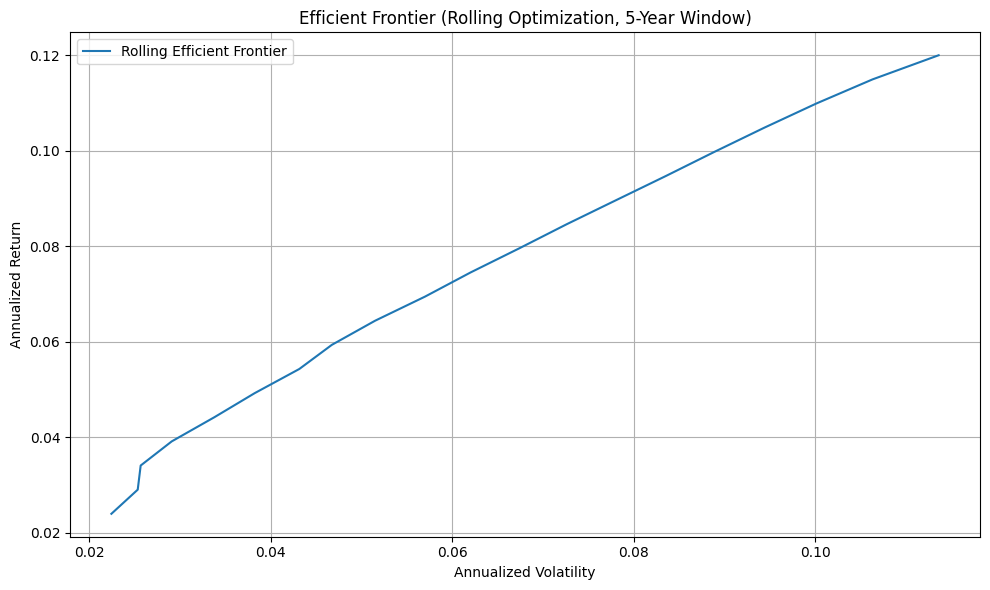

,Return,Volatility
0,0.024000,0.022439
1,0.029053,0.025341
2,0.034105,0.025665
3,0.039158,0.029085
4,0.044211,0.033778
5,0.049263,0.038230
6,0.054316,0.043142
7,0.059368,0.046727
8,0.064421,0.051491
9,0.069474,0.056998


In [ ]:
# 데이터 수집: 2003~2023, 월간 수익률 기준
tickers = {'S&P500': '^GSPC', 'Bond': 'AGG', 'Commodity': 'GSG', 'T-Bill': '^IRX'}
start_date = '2003-01-01'
end_date = '2023-01-01'
price_data = {}

for name, ticker in tickers.items():
    df = yf.download(ticker, start=start_date, end=end_date, interval='1mo')
    if 'Adj Close' in df.columns:
        price_data[name] = df['Adj Close']
    elif 'Close' in df.columns:
        price_data[name] = df['Close']

# 데이터 병합 및 수익률 계산
df_prices = pd.concat(price_data.values(), axis=1)
df_prices.columns = list(price_data.keys())
df_returns = df_prices.pct_change().dropna()

# IRX는 수익률로 간주
df_returns['T-Bill'] = df_prices['T-Bill'] / 100 / 12
df_returns.dropna(inplace=True)

# 롤링 프론티어 계산
rolling_frontiers = []
window = 60  # 5년 (60개월)
target_returns = np.linspace(0.002, 0.01, 20)  # 월간 기대 수익률

def portfolio_return(weights, mean_returns):
    return np.dot(weights, mean_returns)

def portfolio_variance(weights, cov_matrix):
    return np.dot(weights.T, np.dot(cov_matrix, weights))

for start in range(len(df_returns) - window):
    returns_window = df_returns.iloc[start:start+window]
    mean_returns = returns_window.mean()
    cov_matrix = returns_window.cov()
    frontier = []

    for target in target_returns:
        constraints = (
            {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
            {'type': 'eq', 'fun': lambda w: portfolio_return(w, mean_returns) - target}
        )
        bounds = [(0, 1)] * len(mean_returns)
        init_guess = len(mean_returns) * [1. / len(mean_returns)]
        result = minimize(portfolio_variance, init_guess, args=(cov_matrix,), method='SLSQP',
                          bounds=bounds, constraints=constraints)
        if result.success:
            std = np.sqrt(result.fun)
            frontier.append((target * 12, std * np.sqrt(12)))  # 연환산 변환
    if frontier:
        rolling_frontiers.append(frontier)

# 평균 프론티어 계산
frontier_matrix = np.array([f for f in rolling_frontiers if len(f) == len(target_returns)])
mean_frontier = frontier_matrix.mean(axis=0)

# 평균 프론티어 시각화
plt.figure(figsize=(10, 6))
plt.plot([x[1] for x in mean_frontier], [x[0] for x in mean_frontier], label="Rolling Efficient Frontier")
plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.title("Efficient Frontier (Rolling Optimization, 5-Year Window)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 프론티어 평균 수익률, 표준편차 계산
frontier_df = pd.DataFrame(mean_frontier, columns=["Return", "Volatility"])
frontier_df


### 해석
- 선형에 가까운 구조
- 수익률이 증가할수록 리스크도 완만하게 증가 → 시장 구조가 안정적이었음을 의미
- 낮은 리스크 구간 (Vol < 5%)
  - 수익률 증가가 완만하며 효율적 투자 구간이 제한적
  - 위험 회피형 투자자에게 유리
- 중간~고위험 구간 (Vol 6% 이상)
  - 수익률 증가 속도도 상승 → 적극적 투자자에게 효율적인 분산 투자 전략

- 고정 평균/분산을 사용하는 기존 프론티어과 비교
  - 같은 리스크에 비해 수익률이 더 높을 것으로 예측

## Part A-8: 요약 보고서

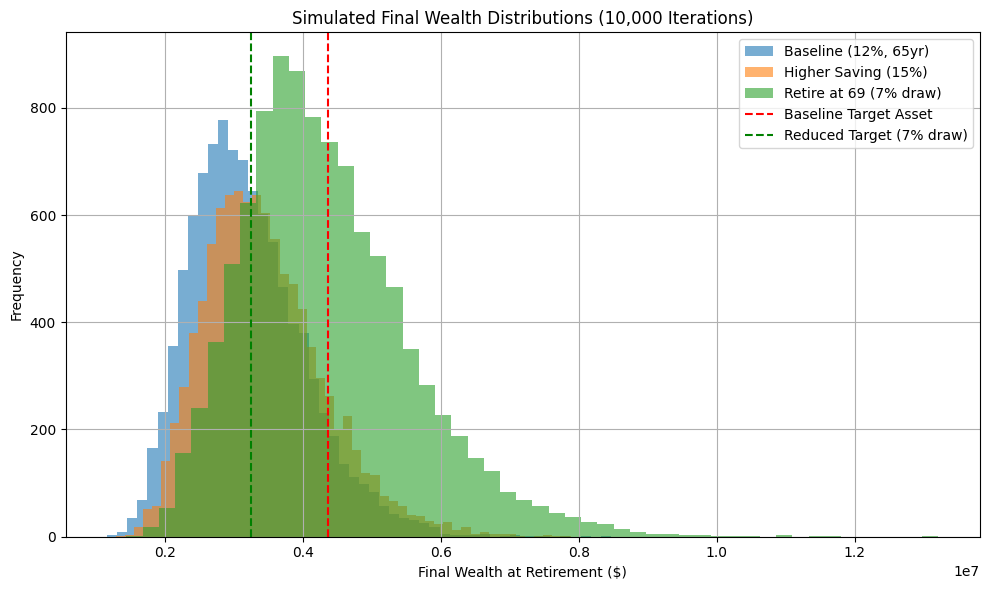

In [ ]:
import matplotlib.pyplot as plt

# 기준, 저축률 증가, 은퇴 연기 시나리오 별 시뮬레이션 분포 데이터 생성
def simulate_final_wealth_distribution(vol, ret, saving_rate, years):
    results = []
    for _ in range(n_sim):
        wealth = initial_wealth
        salary = initial_salary
        for _ in range(years):
            contribution = salary * saving_rate
            wealth = (wealth + contribution) * (1 + np.random.normal(ret, vol))
            salary *= (1 + growth_rate)
        results.append(wealth)
    return np.array(results)

# 각 시나리오별 자산 분포
dist_baseline = simulate_final_wealth_distribution(0.07, 0.07, 0.12, 20)
dist_15pct = simulate_final_wealth_distribution(0.07, 0.07, 0.15, 20)
dist_7pct = simulate_final_wealth_distribution(0.07, 0.07, 0.12, 24)

# 히스토그램 시각화
plt.figure(figsize=(10, 6))
plt.hist(dist_baseline, bins=50, alpha=0.6, label="Baseline (12%, 65yr)")
plt.hist(dist_15pct, bins=50, alpha=0.6, label="Higher Saving (15%)")
plt.hist(dist_7pct, bins=50, alpha=0.6, label="Retire at 69 (7% draw)")

plt.axvline(required_asset_baseline, color='red', linestyle='--', label="Baseline Target Asset")
plt.axvline(required_asset_7pct, color='green', linestyle='--', label="Reduced Target (7% draw)")

plt.xlabel("Final Wealth at Retirement ($)")
plt.ylabel("Frequency")
plt.title("Simulated Final Wealth Distributions (10,000 Iterations)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# 기준 시나리오
initial_wealth = 550000
initial_salary = 160000
growth_rate = 0.03
saving_rate = 0.12
years = 20
n_sim = 10000
ret = 0.07
vol = 0.07

# 평균 연봉 계산 (기준 시나리오)
final_salary = initial_salary * (1 + growth_rate) ** years
avg_last5_salary = np.mean([initial_salary * (1 + growth_rate) ** (years - i) for i in range(5)])
required_asset_baseline = 0.8 * avg_last5_salary / 0.05  # 기준: 80% 소비, 5% 인출

# 시뮬레이션
final_wealths = []
for _ in range(n_sim):
    wealth = initial_wealth
    salary = initial_salary
    for _ in range(years):
        contribution = salary * saving_rate
        annual_return = np.random.normal(ret, vol)
        wealth = (wealth + contribution) * (1 + annual_return)
        salary *= (1 + growth_rate)
    final_wealths.append(wealth)

final_wealths = np.array(final_wealths)

# 대체 리스크 지표 계산
mean_wealth = final_wealths.mean()
std_wealth = final_wealths.std()
VaR_5 = np.percentile(final_wealths, 5)
CVaR_5 = final_wealths[final_wealths <= VaR_5].mean()

# 정리
risk_measures = pd.DataFrame({
    "Measure": [
        "Expected Final Wealth",
        "Standard Deviation",
        "Value at Risk (5%)",
        "Conditional VaR (5%)"
    ],
    "USD Value": [
        mean_wealth,
        std_wealth,
        VaR_5,
        CVaR_5
    ]
})

risk_measures


,Measure,USD Value
0,Expected Final Wealth,3.186936e+06
1,Standard Deviation,8.217360e+05
2,Value at Risk (5%),2.043944e+06
3,Conditional VaR (5%),1.844682e+06
